In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(10,6))
sns.set_style("whitegrid")

<Figure size 1000x600 with 0 Axes>

In [2]:
listings = pd.read_csv("listings.csv")
calendar = pd.read_csv("calendar.csv")

In [3]:
listings.head()

,id,listing_url,scrape_id,last_scraped,name,summary,space,description,experiences_offered,neighborhood_overview,...,review_scores_value,requires_license,license,jurisdiction_names,instant_bookable,cancellation_policy,require_guest_profile_picture,require_guest_phone_verification,calculated_host_listings_count,reviews_per_month
0,241032,https://www.airbnb.com/rooms/241032,20160104002432,2016-01-04,Stylish Queen Anne Apartment,NaN,Make your self at home in this charming one-be...,Make your self at home in this charming one-be...,none,NaN,...,10.0,f,NaN,WASHINGTON,f,moderate,f,f,2,4.07
1,953595,https://www.airbnb.com/rooms/953595,20160104002432,2016-01-04,Bright & Airy Queen Anne Apartment,Chemically sensitive? We've removed the irrita...,"Beautiful, hypoallergenic apartment in an extr...",Chemically sensitive? We've removed the irrita...,none,"Queen Anne is a wonderful, truly functional vi...",...,10.0,f,NaN,WASHINGTON,f,strict,t,t,6,1.48
2,3308979,https://www.airbnb.com/rooms/3308979,20160104002432,2016-01-04,New Modern House-Amazing water view,New modern house built in 2013. Spectacular s...,"Our house is modern, light and fresh with a wa...",New modern house built in 2013. Spectacular s...,none,Upper Queen Anne is a charming neighborhood fu...,...,10.0,f,NaN,WASHINGTON,f,strict,f,f,2,1.15
3,7421966,https://www.airbnb.com/rooms/7421966,20160104002432,2016-01-04,Queen Anne Chateau,A charming apartment that sits atop Queen Anne...,NaN,A charming apartment that sits atop Queen Anne...,none,NaN,...,NaN,f,NaN,WASHINGTON,f,flexible,f,f,1,NaN
4,278830,https://www.airbnb.com/rooms/278830,20160104002432,2016-01-04,Charming craftsman 3 bdm house,Cozy family craftman house in beautiful neighb...,Cozy family craftman house in beautiful neighb...,Cozy family craftman house in beautiful neighb...,none,We are in the beautiful neighborhood of Queen ...,...,9.0,f,NaN,WASHINGTON,f,strict,f,f,1,0.89


In [4]:
listings.info()

<class 'pandas.DataFrame'>
RangeIndex: 3818 entries, 0 to 3817
Data columns (total 92 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   id                                3818 non-null   int64  
 1   listing_url                       3818 non-null   str    
 2   scrape_id                         3818 non-null   int64  
 3   last_scraped                      3818 non-null   str    
 4   name                              3818 non-null   str    
 5   summary                           3641 non-null   str    
 6   space                             3249 non-null   str    
 7   description                       3818 non-null   str    
 8   experiences_offered               3818 non-null   str    
 9   neighborhood_overview             2786 non-null   str    
 10  notes                             2212 non-null   str    
 11  transit                           2884 non-null   str    
 12  thumbnail_url    

In [5]:
calendar.head()

,listing_id,date,available,price
0,241032,2016-01-04,t,$85.00
1,241032,2016-01-05,t,$85.00
2,241032,2016-01-06,f,NaN
3,241032,2016-01-07,f,NaN
4,241032,2016-01-08,f,NaN


In [6]:
calendar.info()

<class 'pandas.DataFrame'>
RangeIndex: 1393570 entries, 0 to 1393569
Data columns (total 4 columns):
 #   Column      Non-Null Count    Dtype
---  ------      --------------    -----
 0   listing_id  1393570 non-null  int64
 1   date        1393570 non-null  str  
 2   available   1393570 non-null  str  
 3   price       934542 non-null   str  
dtypes: int64(1), str(3)
memory usage: 42.5 MB


In [ ]:
listings['price'] = (listings['price'].replace(r'[\$,]', '', regex=True).astype(float))

In [9]:
calendar['date'] = pd.to_datetime(calendar['date'])

In [10]:
calendar['available'] = calendar['available'].map({'t': 1,'f': 0})

In [11]:
calendar['price'] = (calendar['price'].replace(r'[\$,]', '', regex=True).astype(float))

In [12]:
calendar['price'] = calendar['price'].fillna(calendar['price'].median())

In [13]:
occupancy = (calendar.groupby('listing_id')['available']
    .apply(lambda x: (x == 0).sum() / 365)
    .reset_index())
occupancy.columns = ['id', 'occupancy_rate']

In [14]:
listings = listings.merge(occupancy,on='id',how='left')

In [15]:
neighbourhood_stats = (listings.groupby('neighbourhood_cleansed')
     .agg({
        'price':'mean',
        'occupancy_rate':'mean',
        'id':'count'})
    .reset_index())
neighbourhood_stats.columns = [
    'neighbourhood',
    'avg_price',
    'avg_occupancy',
    'listing_count']

In [16]:
top_expensive = neighbourhood_stats.sort_values(
    by='avg_price',
    ascending=False
).head(5)
top_expensive

,neighbourhood,avg_price,avg_occupancy,listing_count
73,Southeast Magnolia,231.705882,0.183562,17
61,Portage Bay,227.857143,0.256360,14
83,Westlake,194.470588,0.388880,17
81,West Queen Anne,187.769231,0.323836,65
48,Montlake,182.789474,0.436770,19


In [17]:
top_cheap = neighbourhood_stats.sort_values(
    by='avg_price'
).head(5)
top_cheap

,neighbourhood,avg_price,avg_occupancy,listing_count
62,Rainier Beach,68.555556,0.270624,18
56,Olympic Hills,71.687500,0.233904,16
70,South Delridge,74.666667,0.284703,12
24,Georgetown,76.125000,0.234247,8
54,North Delridge,76.375000,0.332620,32


In [18]:
top10 = neighbourhood_stats.sort_values(
    by='avg_price',
    ascending=False
).head(10)
bottom10 = neighbourhood_stats.sort_values(
    by='avg_price'
).head(10)

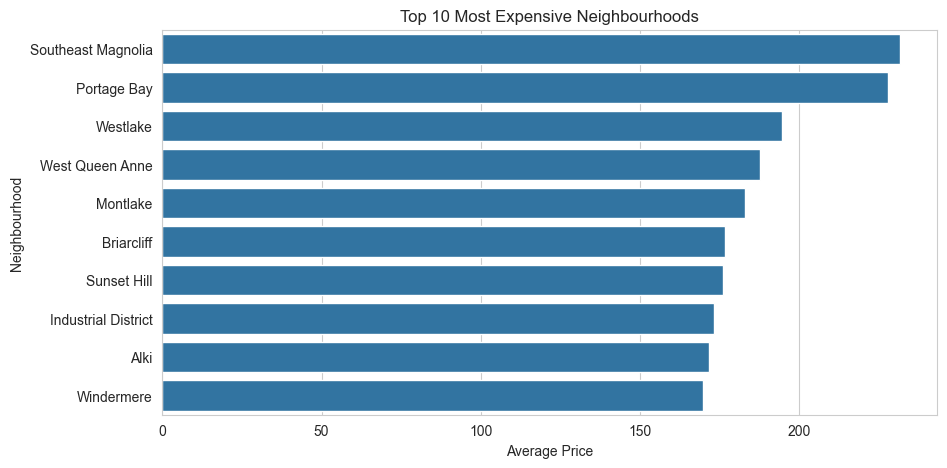

In [20]:
plt.figure(figsize=(10,5))
sns.barplot(
    data=top10,
    x='avg_price',
    y='neighbourhood')
plt.title("Top 10 Most Expensive Neighbourhoods")
plt.xlabel("Average Price")
plt.ylabel("Neighbourhood")
plt.show()

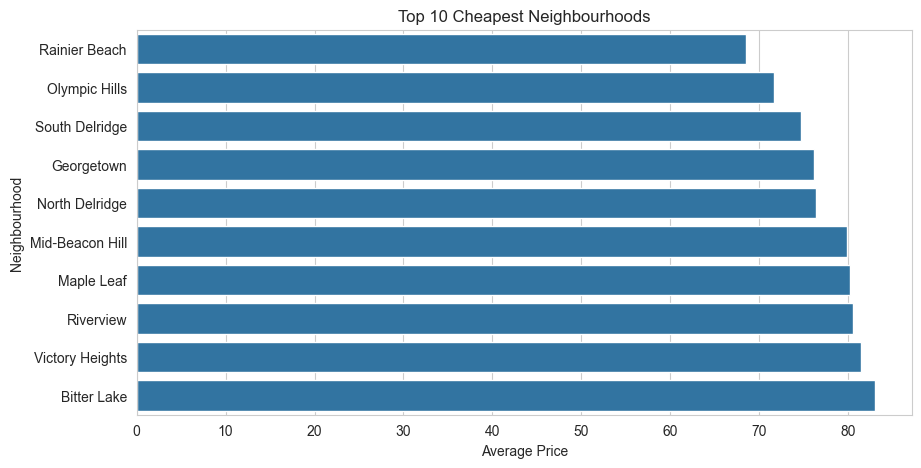

In [21]:
plt.figure(figsize=(10,5))
sns.barplot(
    data=bottom10,
    x='avg_price',
    y='neighbourhood')
plt.title("Top 10 Cheapest Neighbourhoods")
plt.xlabel("Average Price")
plt.ylabel("Neighbourhood")
plt.show()

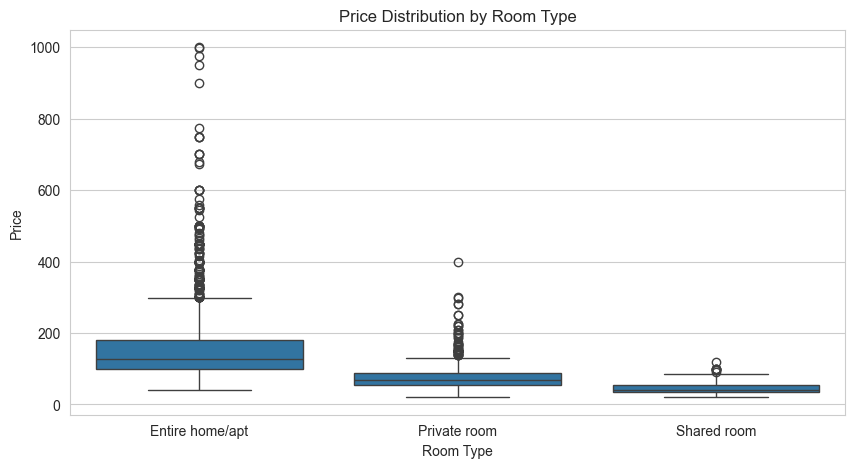

In [23]:
plt.figure(figsize=(10,5))
sns.boxplot(
    data=listings,
    x='room_type',
    y='price')
plt.title("Price Distribution by Room Type")
plt.xlabel("Room Type")
plt.ylabel("Price")
plt.show()

In [24]:
calendar['month'] = calendar['date'].dt.month

In [25]:
monthly_prices = (
    calendar.groupby('month')['price']
    .mean()
    .reset_index())

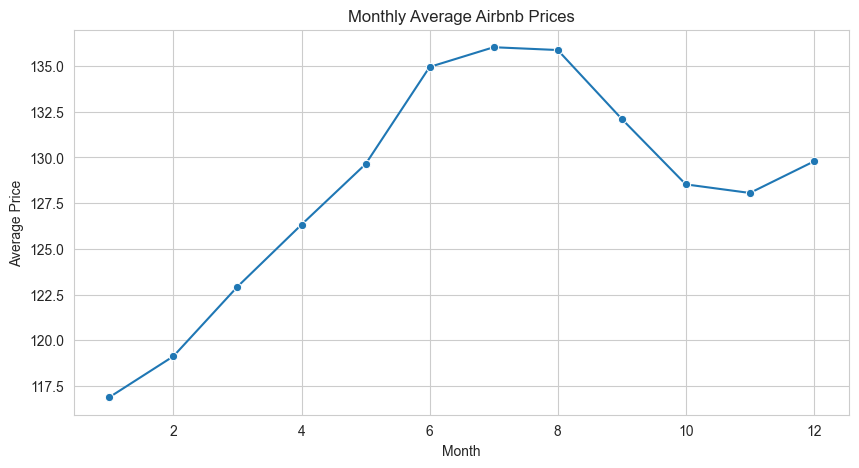

In [27]:
plt.figure(figsize=(10,5))
sns.lineplot(
    data=monthly_prices,
    x='month',
    y='price',
    marker='o')
plt.title("Monthly Average Airbnb Prices")
plt.xlabel("Month")
plt.ylabel("Average Price")
plt.show()

In [28]:
listings['instant_bookable'] = listings[
    'instant_bookable'
].map({
    't':'Instant',
    'f':'Not Instant'})

In [29]:
instant_stats = (
    listings.groupby('instant_bookable')
    .agg({
        'price':'mean',
        'occupancy_rate':'mean'}))

In [30]:
instant_stats

,price,occupancy_rate
instant_bookable,,
Instant,121.289340,0.326352
Not Instant,129.200806,0.329946


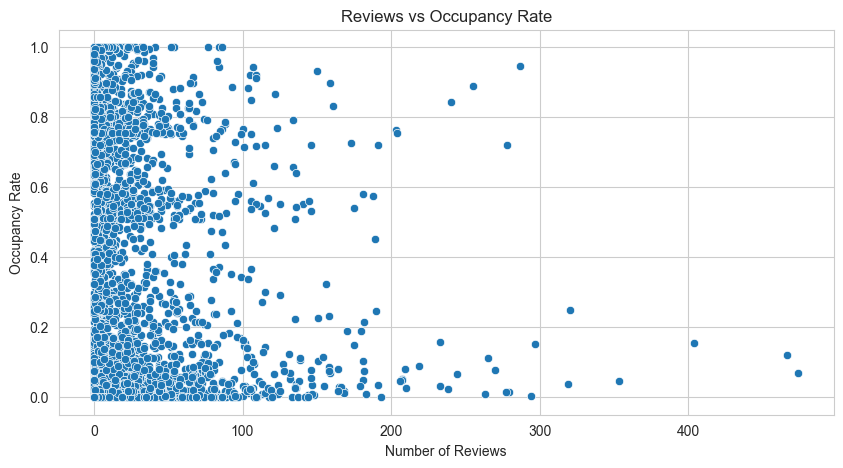

In [31]:
plt.figure(figsize=(10,5))
sns.scatterplot(
    data=listings,
    x='number_of_reviews',
    y='occupancy_rate')
plt.title("Reviews vs Occupancy Rate")
plt.xlabel("Number of Reviews")
plt.ylabel("Occupancy Rate")
plt.show()

In [32]:
correlation = listings[
    ['number_of_reviews', 'occupancy_rate']
].corr()
correlation

,number_of_reviews,occupancy_rate
number_of_reviews,1.000000,-0.094273
occupancy_rate,-0.094273,1.000000


In [ ]:
median_price = listings['price'].median()
listings['revenue_potential'] = (listings['occupancy_rate']* median_price* 365)#bonus

In [34]:
revenue_neighbourhood = (
    listings.groupby('neighbourhood_cleansed')
    ['revenue_potential']
    .mean()
    .sort_values(ascending=False)
    .reset_index())
revenue_neighbourhood.head(10)

,neighbourhood_cleansed,revenue_potential
0,South Lake Union,19955.555556
1,South Beacon Hill,18175.000000
2,North Beach/Blue Ridge,17742.857143
3,Seaview,17408.333333
4,Riverview,16637.500000
5,Montlake,15942.105263
6,Madrona,15872.340426
7,Lower Queen Anne,15787.234043
8,Genesee,15479.411765
9,First Hill,14925.925926


In [35]:
best_revenue_area = revenue_neighbourhood.iloc[0]
best_revenue_area

neighbourhood_cleansed    South Lake Union
revenue_potential             19955.555556
Name: 0, dtype: object